[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)
## Fourier Series Calculus, Signal and Property Examples

seems to be obsolete, check...

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def coeffRealA(k, A, T, T_h):
    if k == 0:
        return A*T_h/T
    else:
        return 2*A/(k*np.pi)*np.sin(k*np.pi*T_h/T)


def coeffRealB(k, A, T, T_h):
    if k == 0:
        return 0
    else:
        return 2*A/(np.pi*k)*(1-np.cos(k*np.pi*T_h/T))


def coeffRealC(k, A, T, T_h):
    if k == 0:
        return A*T_h/(2*T)
    else:
        return 2*A*T/(T_h*k**2*np.pi**2)*(1-np.cos(k*np.pi*T_h/T))

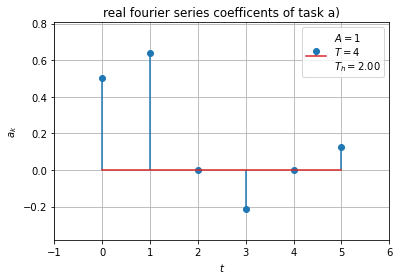

In [3]:
plt.close()
index = 0
A = 1
T = 4
T_h = 2
kmax = 5
t = np.arange(-2*T, 2*T, 1/10000)
x = np.zeros(t.size)
for k in range(0, kmax+1):
    x += coeffRealA(k=k, A=A, T=T, T_h=T_h)*np.cos(k*2*np.pi/T*t)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tt = np.arange(-3/4*T, 3/4*T, 1/10000)
plt.xlabel('$t$')
plt.ylabel('$a_k\\cdot\\cos(k\\omega t)$ and $\\frac{a_0}{2}$')
for k in range(0, kmax+1):
    plt.plot(tt, coeffRealA(k, A=A, T=T, T_h=T_h) *
             np.cos(k*2*np.pi/T*tt), label='$k=$%d' % (k))
plt.grid(True)
plt.ylim(-A, A)
plt.xticks(np.arange(-3/4*T, 3/4*T, T/4))
plt.xlim(tt[0], tt[tt.size-1])
s = 'Fourier series components of task a)'
plt.title(s)
plt.legend(loc=1)
plt.subplot(1, 2, 2)
plt.xlabel('$t$')
plt.ylabel('$x_a(t)$')
plt.plot(t, x, 'b', label='$T=%d$\n$T_h=%.1f$\n$0 \leq k \leq %d$' %
         (T, T_h, kmax))
plt.ylim(np.amin(x)-np.abs(np.amax(x)-np.amin(x))/5,
         np.amax(x)+np.abs(np.amax(x)-np.amin(x))/5)
plt.grid(True)
plt.legend(loc='lower center')
plt.xticks(np.arange(-2*T, 2*T, T/2))
plt.xlim(t[0], t[t.size-1])
s = 'real fourier series task a)'
plt.title(s)
plt.savefig('Fourierseries_'+str(index)+'.pdf')  # Name wird benötigt
plt.close()
k = np.arange(start=0, stop=kmax+1, step=1)
plt.xlabel('$t$')
plt.ylabel('$a_k$')
s = 'real fourier series coefficents of task a)'
plt.title(s)
ak = np.zeros(kmax+1)
for i in range(0, kmax+1):
    ak[i] = coeffRealA(k=i, A=A, T=T, T_h=T_h)
plt.ylim(np.amin(np.real(ak))-np.abs(np.amax(np.real(ak))-np.amin(np.real(ak)))/5,
         np.amax(np.real(ak))+np.abs(np.amax(np.real(ak))-np.amin(np.real(ak)))/5)
plt.grid(True)
plt.xticks(np.arange(-1, kmax+2, 1))
plt.xlim(-1, kmax+1)
plt.stem(k, ak, label='$A=%d$\n$T=%d$\n$T_h=%.2f$' % (A, T, T_h))
plt.legend()
plt.savefig('Fourierseriescoeff_'+str(index)+'.pdf')

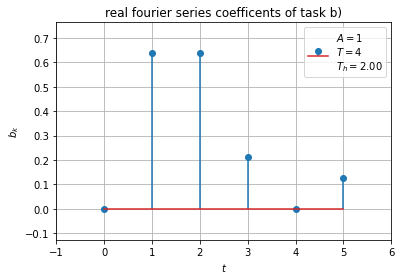

In [4]:
plt.close()
index = 1
A = 1
T = 4
T_h = 2
kmax = 5
t = np.arange(-2*T, 2*T, 1/10000)
x = np.zeros(t.size)
for k in range(0, kmax+1):
    x += coeffRealB(k=k, A=A, T=T, T_h=T_h)*np.sin(k*2*np.pi/T*t)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tt = np.arange(-3/4*T, 3/4*T, 1/10000)
plt.xlabel('$t$')
plt.ylabel('$b_k\\cdot\\sin(k\\omega t)$')
for k in range(0, kmax+1):
    plt.plot(tt, coeffRealA(k, A=A, T=T, T_h=T_h) *
             np.cos(k*2*np.pi/T*tt), label='$k=$%d' % (k))
plt.grid(True)
plt.ylim(-A, A)
plt.xticks(np.arange(-3/4*T, 3/4*T, T/4))
plt.xlim(tt[0], tt[tt.size-1])
s = 'Fourier series components of task b)'
plt.title(s)
plt.legend(loc=1)
plt.subplot(1, 2, 2)
plt.xlabel('$t$')
plt.ylabel('$x_b(t)$')
plt.plot(t, x, 'b', label='$T=%d$\n$T_h=%.1f$\n$0 \leq k \leq %d$' %
         (T, T_h, kmax))
plt.ylim(np.amin(x)-np.abs(np.amax(x)-np.amin(x))/5,
         np.amax(x)+np.abs(np.amax(x)-np.amin(x))/5)
plt.grid(True)
plt.legend(loc='lower center')
plt.xticks(np.arange(-2*T, 2*T, T/2))
plt.xlim(t[0], t[t.size-1])
s = 'real fourier series task b)'
plt.title(s)
plt.savefig('Fourierseries_'+str(index)+'.pdf')  # Name wird benötigt
plt.close()
k = np.arange(start=0, stop=kmax+1, step=1)
plt.xlabel('$t$')
plt.ylabel('$b_k$')
s = 'real fourier series coefficents of task b)'
plt.title(s)
ak = np.zeros(kmax+1)
for i in range(0, kmax+1):
    ak[i] = coeffRealB(k=i, A=A, T=T, T_h=T_h)
plt.ylim(-1/5*np.amax(ak), 6/5*np.amax(ak))
plt.grid(True)
plt.xticks(np.arange(-1, kmax+2, 1))
plt.xlim(-1, kmax+1)
plt.stem(k, ak, label='$A=%d$\n$T=%d$\n$T_h=%.2f$' % (A, T, T_h))
plt.legend()
plt.savefig('Fourierseriescoeff_'+str(index)+'.pdf')

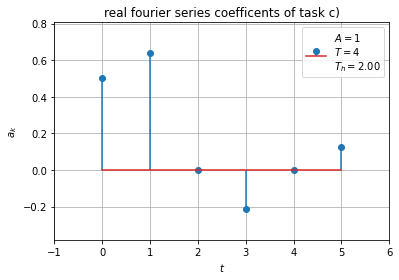

In [5]:
plt.close()
index = 2
A = 1
T = 4
T_h = 2
kmax = 5
t = np.arange(-2*T, 2*T, 1/10000)
x = np.zeros(t.size)
for k in range(0, kmax+1):
    x += coeffRealC(k=k, A=A, T=T, T_h=T_h)*np.cos(k*2*np.pi/T*t)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
tt = np.arange(-3/4*T, 3/4*T, 1/10000)
plt.xlabel('$t$')
plt.ylabel('$a_k\\cdot\\cos(k\\omega t)$ and $\\frac{a_0}{2}$')
for k in range(0, kmax+1):
    plt.plot(tt, coeffRealA(k, A=A, T=T, T_h=T_h) *
             np.cos(k*2*np.pi/T*tt), label='$k=$%d' % (k))
plt.grid(True)
plt.ylim(-A, A)
plt.xticks(np.arange(-3/4*T, 3/4*T, T/4))
plt.xlim(tt[0], tt[tt.size-1])
s = 'Fourier series components of task c)'
plt.title(s)
plt.legend(loc=1)
plt.subplot(1, 2, 2)
plt.xlabel('$t$')
plt.ylabel('$x_c(t)$')
plt.plot(t, x, 'b', label='$T=%d$\n$T_h=%.1f$\n$0 \leq k \leq %d$' %
         (T, T_h, kmax))
plt.ylim(np.amin(x)-np.abs(np.amax(x)-np.amin(x))/5,
         np.amax(x)+np.abs(np.amax(x)-np.amin(x))/5)
plt.grid(True)
plt.legend(loc='lower center')
plt.xticks(np.arange(-2*T, 2*T, T/2))
plt.xlim(t[0], t[t.size-1])
s = 'real fourier series task c)'
plt.title(s)
plt.savefig('Fourierseries_'+str(index)+'.pdf')  # Name wird benötigt
plt.close()
k = np.arange(start=0, stop=kmax+1, step=1)
plt.xlabel('$t$')
plt.ylabel('$a_k$')
s = 'real fourier series coefficents of task c)'
plt.title(s)
ak = np.zeros(kmax+1)
for i in range(0, kmax+1):
    ak[i] = coeffRealA(k=i, A=A, T=T, T_h=T_h)
plt.ylim(np.amin(np.real(ak))-np.abs(np.amax(np.real(ak))-np.amin(np.real(ak)))/5,
         np.amax(np.real(ak))+np.abs(np.amax(np.real(ak))-np.amin(np.real(ak)))/5)
plt.grid(True)
plt.xticks(np.arange(-1, kmax+2, 1))
plt.xlim(-1, kmax+1)
plt.stem(k, ak, label='$A=%d$\n$T=%d$\n$T_h=%.2f$' % (A, T, T_h))
plt.legend()
plt.savefig('Fourierseriescoeff_'+str(index)+'.pdf')

In [6]:
def plot_complex_fourierseries(A, T, T_h, coeff, index, kmin, kmax, task, omega):
    plt.close()
    t = np.arange(-2*T, 2*T, 1/(10000))
    x = np.zeros(t.size, dtype=complex)
    for k in range(kmin, kmax+1):
        x += coeff(k=k, A=A, T=T, T_h=T_h)*np.exp(1j*omega*k*t)
    plt.ylabel('$\Re \{x_{%s}(t)\}$' % (task))
    plt.xlabel('$t$')
    s = 'fourier series of task '+task+') with complex coefficents'
    plt.title(s)
    plt.grid(True)
    plt.xticks(np.arange(start=-3*T, stop=3*T, step=1/2*T))
    plt.xlim(-2*T, 2*T)
    if np.abs(np.amax(np.real(x))-np.amin(np.real(x))) < 10/7:
        plt.ylim(np.amin(np.real(x))+np.abs(np.amax(np.real(x))-np.amin(np.real(x))) /
                 2-1, np.amin(np.real(x))+np.abs(np.amax(np.real(x))-np.amin(np.real(x)))/2+1)
    else:
        plt.ylim(np.amin(np.real(x))-np.abs(np.amax(np.real(x))-np.amin(np.real(x)))/5,
                 np.amax(np.real(x))+np.abs(np.amax(np.real(x))-np.amin(np.real(x)))/5)
    plt.plot(t, np.real(x), label='$T=%d$\n$T_h=%d$\n$%d\leq k \leq %d$' %
             (2*np.pi/omega, 2*np.pi/(omega*T)*T_h, kmin, kmax))
    plt.legend()
    plt.savefig('Fourierseries_'+str(index)+'.pdf')
    k = np.arange(start=kmin, stop=kmax+1, step=1)
    ckm = np.zeros(k.size, dtype=complex)
    ckp = np.zeros(k.size, dtype=complex)
    i = kmin
    while i <= kmax:
        ckm[i+kmax] = coeff(k=i, A=A, T=T, T_h=T_h)
        i += 1
    ckp = np.angle(ckm+0)
    ckm = np.abs(ckm)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.xlabel('$k$')
    plt.ylabel('$|c_k|$')
    s = 'fourier coefficent magnitude of task '+task+')'
    plt.title(s)
    plt.grid(True)
    plt.xticks(np.arange(kmin-1, kmax+2, 1))
    plt.xlim(kmin-1, kmax+1)
    plt.ylim(-1/5*np.amax(ckm), 6/5*np.amax(ckm))
    plt.stem(k, ckm)
    plt.subplot(1, 2, 2)
    plt.ylabel('$\\varphi(k)$')
    plt.xlabel('k')
    s = 'fourier coefficent phase of task '+task+')'
    plt.title(s)
    plt.grid(True)
    plt.xticks(np.arange(kmin-1, kmax+2, 1))
    plt.xlim(kmin-1, kmax+1)
    plt.ylim(-6/5*np.pi, 6/5*np.pi)
    plt.stem(k, ckp)
    plt.savefig('Fourierseriescoeff_'+str(index)+'.pdf')
    plt.close()

In [7]:
def coeffAComplex(k, A, T, T_h):
    if k == 0:
        return A*T_h/T
    else:
        return A/(np.pi*k)*np.sin(k*np.pi*T_h/T)


def coeffBComplex(k, A, T, T_h):
    if k == 0:
        return 0
    else:
        return A/(1j*k*np.pi)*(1-np.cos(k*np.pi*T_h/T))


def coeffCComplex(k, A, T, T_h):
    if k == 0:
        return A*T_h/(2*T)
    else:
        return A*T/(T_h*k**2*np.pi**2)*(1-np.cos(k*np.pi*T_h/T))


def coeffDComplex(k, A, T, T_h):
    return 1*coeffAComplex(k=k, A=A, T=T, T_h=T_h)+1j*coeffBComplex(k=k, A=A, T=T, T_h=T_h)


def coeffEComplex(k, A, T, T_h):
    return np.exp(-1j*k*2*np.pi/T*T_h/2)*coeffAComplex(k=k, A=A, T=T, T_h=T_h)


def coeffFComplex(k, A, T, T_h):
    return coeffAComplex(k=k-3, A=A, T=T, T_h=T_h)


def coeffGComplex(k, A, T, T_h):
    return coeffBComplex(k=-k, A=A, T=T, T_h=T_h)


def coeffHComplex(k, A, T, T_h):
    return T*coeffAComplex(k=k, A=A, T=T, T_h=T_h)*coeffBComplex(k=k, A=A, T=T, T_h=T_h)


def coeffIComplex(k, A, T, T_h):
    return 1j*k*2*np.pi/T*coeffCComplex(k=k, A=A, T=T, T_h=T_h)


def coeffJComplex(k, A, T, T_h):
    return coeffAComplex(k=k, A=A, T=T, T_h=T_h)


def coeffKComplex(k, A, T, T_h):
    if k == 0:
        return 1
    else:
        return 0


def coeffLComplex(k, A, T, T_h):
    if k == 0:
        return 0
    else:
        return A**2/(1j*k*np.pi)+1j*A**2*T/(T_h*k**2*np.pi**2)*np.sin(k*np.pi+T_h/T)


def coeffMComplex(k, A, T, T_h):
    if k == 0:
        return 0
    else:
        return T/(2j*k*np.pi)*coeffBComplex(k=k, A=A, T=T, T_h=T_h)


coeff = [coeffAComplex, coeffBComplex, coeffCComplex, coeffDComplex, coeffEComplex, coeffFComplex,
         coeffGComplex, coeffHComplex, coeffIComplex, coeffJComplex, coeffKComplex, coeffLComplex, coeffMComplex]

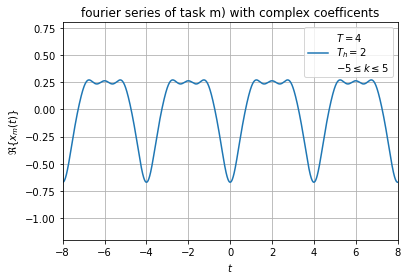

In [8]:
index = 3
character = 97
for i in coeff:
    if chr(character) == 'j':
        plot_complex_fourierseries(A=1, T=4, T_h=2, kmin=-5, kmax=5,
                                   coeff=i, index=index, task=chr(character), omega=np.pi/4)
    else:
        plot_complex_fourierseries(A=1, T=4, T_h=2, kmin=-5, kmax=5,
                                   coeff=i, index=index, task=chr(character), omega=np.pi/2)
    index += 1
    character += 1

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.